In [ ]:
from keras.models import Model
from keras.layers import Input,Dense

In [2]:
x = Input(shape=(3,))

In [3]:
hidden1 = Dense(10, activation='relu')(x)
hidden2 = Dense(10, activation='relu')(hidden1)

E0000 00:00:1778000849.296410   88602 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
output1 = Dense(1, activation='linear')(hidden2)
output2 = Dense(1, activation='sigmoid')(hidden2)

In [5]:
model = Model(inputs=x, outputs=[output1, output2])

In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │         40 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │        110 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         11 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         11 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 172 (688.00 B)

 Trainable params: 172 (688.00 B)

 Non-trainable params: 0 (0.00 B)

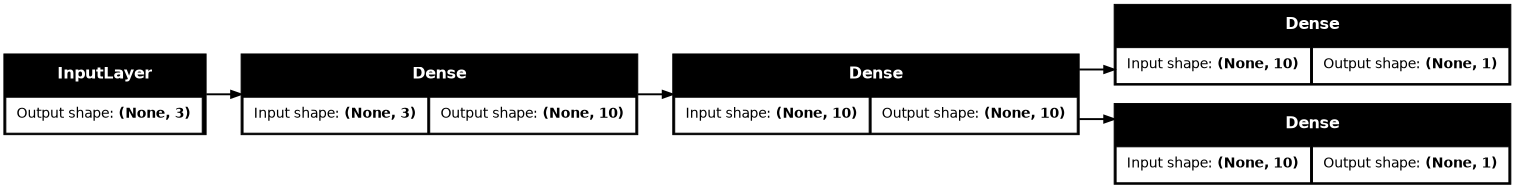

In [12]:
from keras.utils import plot_model
plot_model(model, dpi=70, rankdir='LR', show_shapes=True)

## multiple-input

In [13]:
# defined two sets of inputs
input1 = Input(shape=(128,))
input2 = Input(shape=(32,))

In [14]:
# branch1
x = Dense(8, activation='relu')(input2)
x1 = Dense(4, activation='relu')(x)

In [15]:
# branch2
y = Dense(64, activation='relu')(input1)
y1 = Dense(32, activation='relu')(y)
y2 = Dense(4, activation='relu')(y1)

In [16]:
# concatenate the outputs of the two branches
from keras.layers import concatenate
combined = concatenate([x1, y2])

In [17]:
z = Dense(2, activation='relu')(combined)
z1 = Dense(1, activation='linear')(z)

In [18]:
model = Model(inputs=[x,y], outputs=z1)

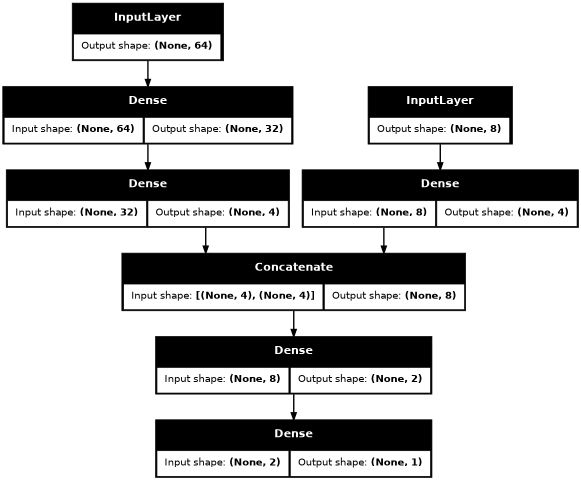

In [22]:
plot_model(model, dpi=50, rankdir='TB', show_shapes=True)